In [1]:
import pandas as pd

df = pd.read_parquet("../data/raw/diabetes_obesity_raw.parquet")
df.head()


,Id_diabetes,IndicatorCode_diabetes,SpatialDimType_diabetes,country_code,ParentLocationCode_diabetes,TimeDimType_diabetes,ParentLocation,Dim1Type_diabetes,year,Dim1,...,DataSourceDim_obesity,Value_obesity,feature_obesity,Low_obesity,High_obesity,Comments_obesity,Date_obesity,TimeDimensionValue_obesity,TimeDimensionBegin_obesity,TimeDimensionEnd_obesity
0,5182635,NCD_GLUC_04,COUNTRY,TTO,AMR,YEAR,Americas,SEX,2005,SEX_BTSX,...,None,22.3 [20.2-24.6],22.317809,20.150678,24.561279,None,2024-02-29T16:06:41.017+01:00,2005,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00
1,5184356,NCD_GLUC_04,COUNTRY,LBY,EMR,YEAR,Eastern Mediterranean,SEX,1997,SEX_BTSX,...,None,22.2 [19.1-25.5],22.198328,19.061823,25.525525,None,2024-02-29T16:06:41.017+01:00,1997,1997-01-01T00:00:00+01:00,1997-12-31T00:00:00+01:00
2,5185484,NCD_GLUC_04,COUNTRY,HUN,EUR,YEAR,Europe,SEX,1997,SEX_BTSX,...,None,16.3 [14.5-18.3],16.303177,14.470547,18.273266,None,2024-02-29T16:06:41.017+01:00,1997,1997-01-01T00:00:00+01:00,1997-12-31T00:00:00+01:00
3,5186199,NCD_GLUC_04,REGION,AFR,None,YEAR,None,SEX,2005,SEX_BTSX,...,None,7.3 [7.1-7.6],7.321556,7.097165,7.566333,None,2024-05-23T13:35:20.483+02:00,2005,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00
4,5189129,NCD_GLUC_04,COUNTRY,GUY,AMR,YEAR,Americas,SEX,1994,SEX_BTSX,...,None,11.0 [8.5-13.8],10.993333,8.503269,13.772142,None,2024-02-29T16:06:41.017+01:00,1994,1994-01-01T00:00:00+01:00,1994-12-31T00:00:00+01:00


In [2]:
numeric_df = df.select_dtypes(include="number")
numeric_df.shape

(5075, 9)

In [3]:
y = numeric_df["target_diabetes"]
X = numeric_df.drop(columns=["target_diabetes"])

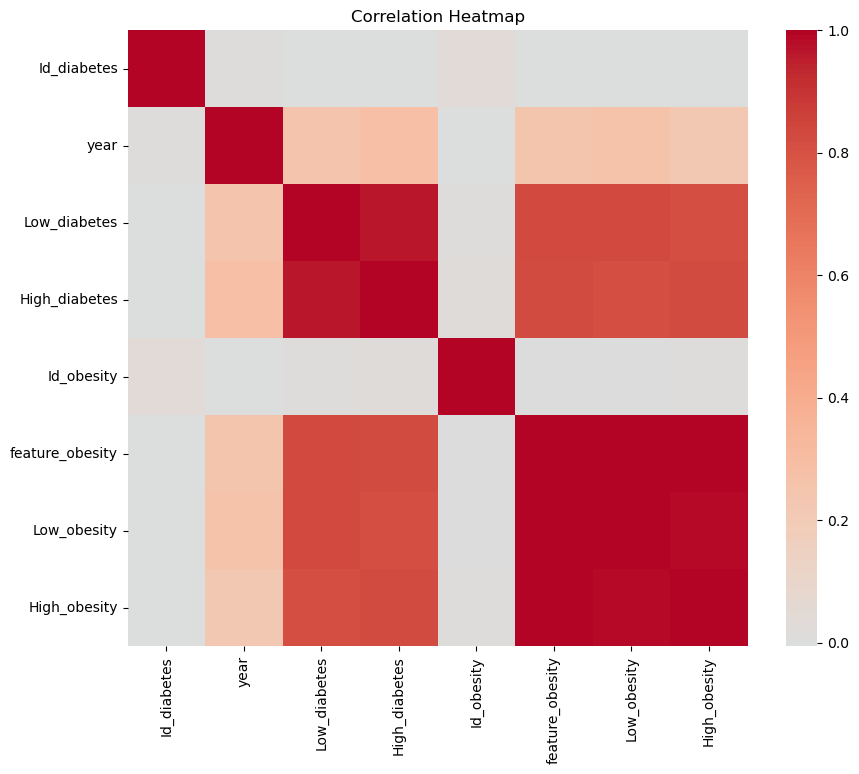

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
import pandas as pd

numeric_df = df.select_dtypes(include="number")

y = numeric_df["target_diabetes"]

X = numeric_df.drop(columns=[
    "target_diabetes",
    "Low_diabetes",
    "High_diabetes",
    "Low_obesity",
    "High_obesity"
])

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
1,year,8.481979
0,Id_diabetes,4.041843
2,Id_obesity,4.026719
3,feature_obesity,2.681993


In [8]:
X_clean = df.select_dtypes(include="number").drop(columns=[
    "target_diabetes",
    "Id_diabetes",
    "Id_obesity",
    "Low_diabetes",
    "High_diabetes",
    "Low_obesity",
    "High_obesity"
])

In [9]:
vif_clean = pd.DataFrame()
vif_clean["feature"] = X_clean.columns
vif_clean["VIF"] = [
    variance_inflation_factor(X_clean.values, i)
    for i in range(X_clean.shape[1])
]

vif_clean.sort_values("VIF", ascending=False)

,feature,VIF
0,year,2.681732
1,feature_obesity,2.681732
